In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df = pd.DataFrame(df)
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.duplicated().sum()

np.int64(0)

Distribution

In [6]:
df['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

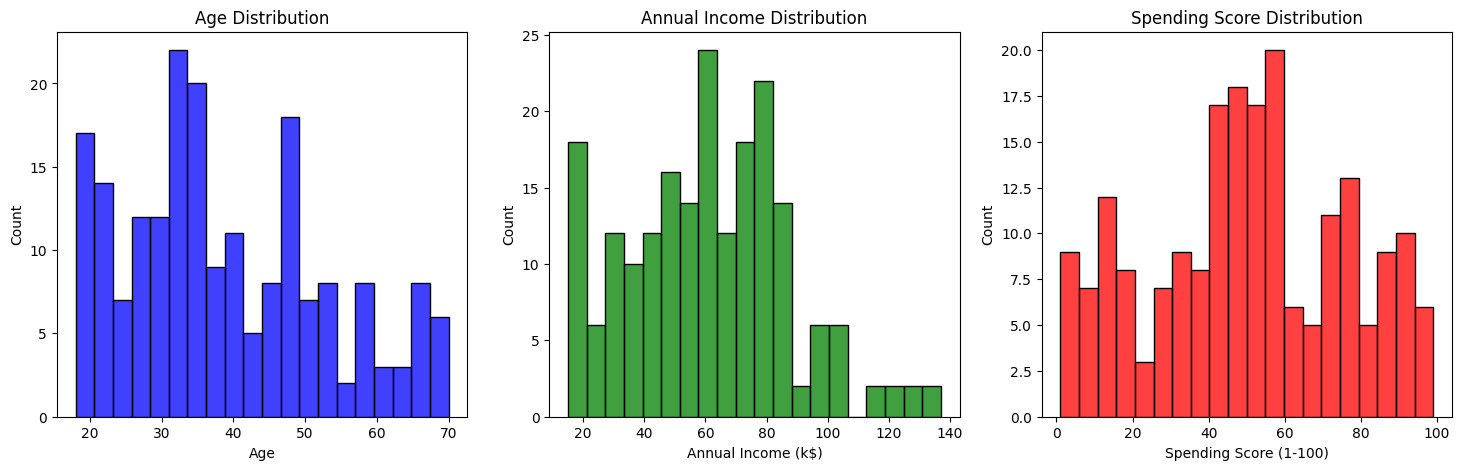

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=20,color='blue', ax=axs[0])
axs[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], bins=20, color='green', ax=axs[1])
axs[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], bins=20,color='red', ax=axs[2])
axs[2].set_title('Spending Score Distribution')

plt.show()





Trends:

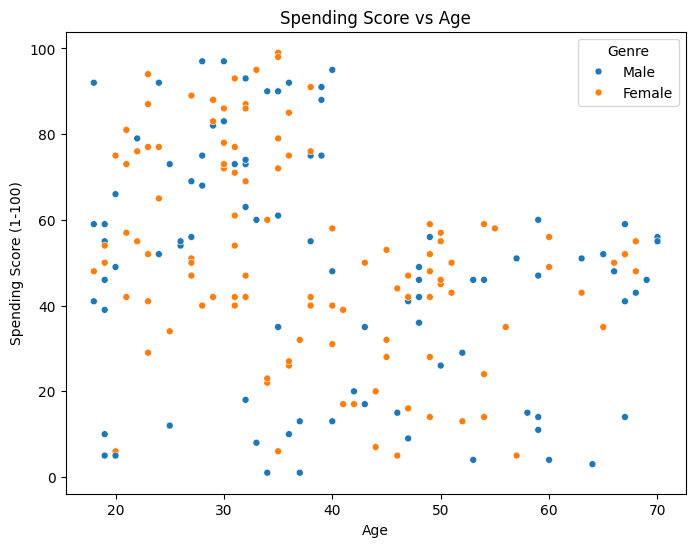

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Genre', s=25)
plt.title('Spending Score vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show()

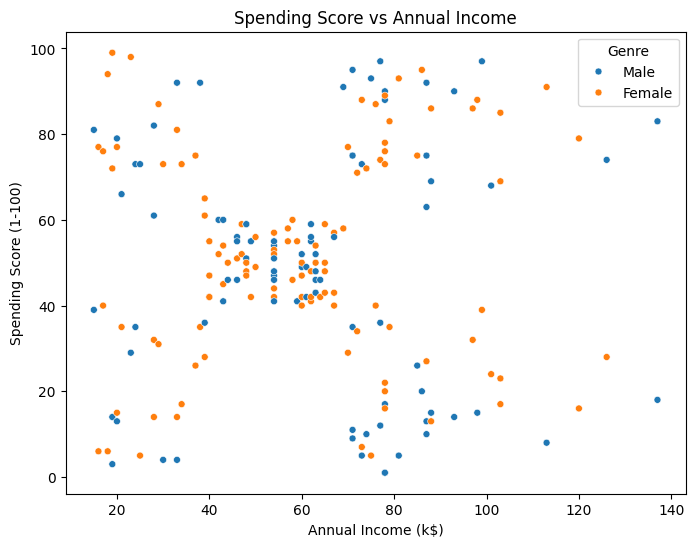

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Genre', s=25)
plt.title('Spending Score vs Annual Income')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

* The above graph shows clear 5 clusters, hence Annual Income and Spending are more helpful for clustering.


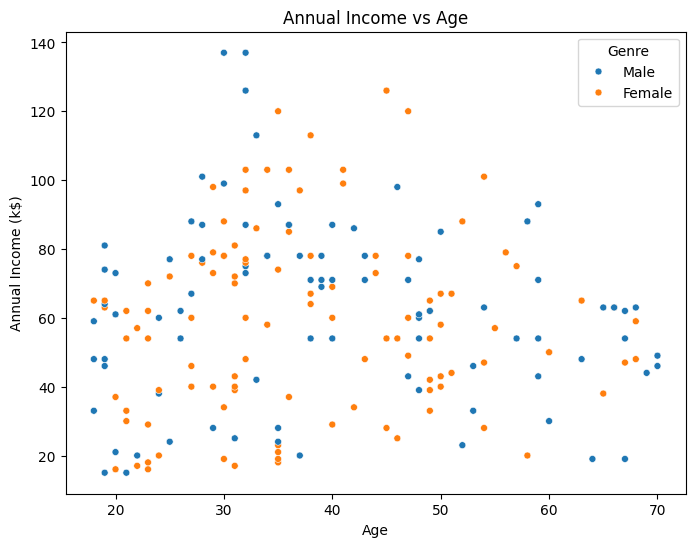

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='Annual Income (k$)', hue='Genre', s=25)
plt.title('Annual Income vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

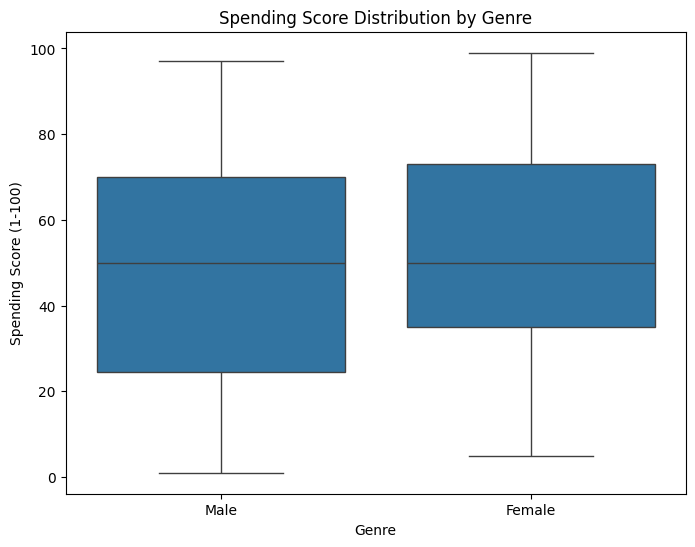

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Genre', y='Spending Score (1-100)')
plt.title('Spending Score Distribution by Genre')
plt.show()

* This suggests that females tend to spend a bit more than men.(FACT)

In [12]:
df.drop(columns=['CustomerID'], inplace=True)

In [13]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
label_encoder = LabelEncoder()
df['Genre'] = label_encoder.fit_transform(df['Genre'])

In [14]:
df_s = df.drop(columns=['Genre'])
scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df_s), columns=df_s.columns)

In [15]:
df_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [16]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


---
## K-Means Clustering with 3 Features (Income, Age & Spending Score)

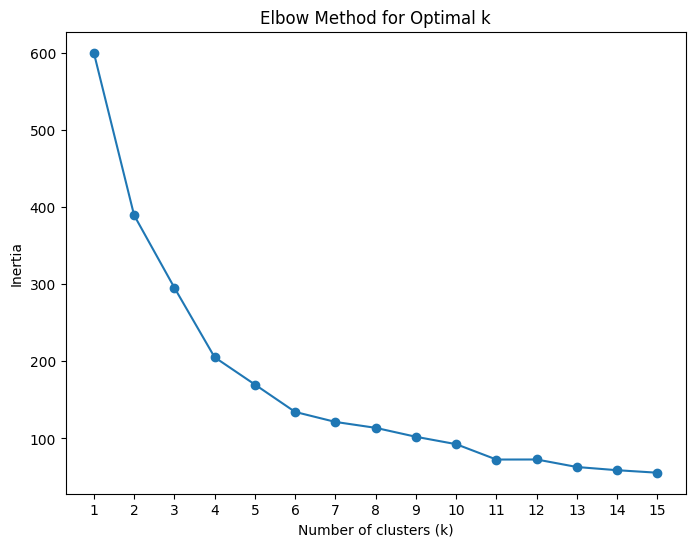

In [17]:
from sklearn.cluster import KMeans
inertia = []
k_range = range(1, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

In [18]:
kmeans = KMeans(n_clusters=6, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)

In [19]:
from sklearn.metrics import silhouette_score
kmeans_score = silhouette_score(df_scaled, kmeans.labels_)
print(f"K-Means Silhouette Score: {kmeans_score:.2f}")


from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(df_scaled, kmeans.labels_)
print(f"Davies-Bouldin Score: {db_score:.2f}")




K-Means Silhouette Score: 0.43
Davies-Bouldin Score: 0.83


In [20]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,5
3,0,23,16,77,2
4,0,31,17,40,5


In [21]:
import plotly.express as px # type: ignore
fig = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y="Spending Score (1-100)",
    z="Age",
    color="KMeans_Cluster",
    color_continuous_scale="Viridis"
)


fig.update_traces(marker=dict(size=3))

fig.show()


In [22]:
cluster_summary = df.groupby('KMeans_Cluster').agg({
    'Age': ['min', 'max', 'mean'],
    'Annual Income (k$)': ['min', 'max', 'mean'],
    'Spending Score (1-100)': ['min', 'max', 'mean']
})
cluster_summary['Customer_Count'] = df.groupby('KMeans_Cluster').size()
cluster_summary['Male_Count'] = df.groupby('KMeans_Cluster')['Genre'].sum()
cluster_summary['Female_Count'] = df.groupby('KMeans_Cluster')['Genre'].apply(lambda x: (x == 0).sum())
cluster_summary = cluster_summary.round(2)

cluster_summary


Age            Annual Income (k$)              \
               min max   mean                min  max   mean   
KMeans_Cluster                                                 
0               43  70  56.33                 38   79  54.27   
1               27  40  32.69                 69  137  86.54   
2               18  35  25.56                 15   42  26.48   
3               18  40  26.12                 40   81  59.42   
4               32  59  44.00                 71  137  90.13   
5               20  67  45.52                 16   39  26.29   

               Spending Score (1-100)            Customer_Count Male_Count  \
                                  min max   mean                             
KMeans_Cluster                                                               
0                                  35  60  49.07             45         19   
1                                  63  97  82.13             39         18   
2                                  39  99  76.24             25         11   
3                                   5  60  44.45             40         16   
4                                   1  39  17.93             30         16   
5                                   3  40  19.38             21          8   

               Female_Count  
                             
KMeans_Cluster               
0                        26  
1                        21  
2                        14  
3                        24  
4                        14  
5                        13

---
## K-Means Clustering with 2 Features (Income & Spending Score)

In [23]:

df_scaled_2f = df_scaled.drop(columns=['Age'])
df_scaled_2f.head()

,Annual Income (k$),Spending Score (1-100)
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


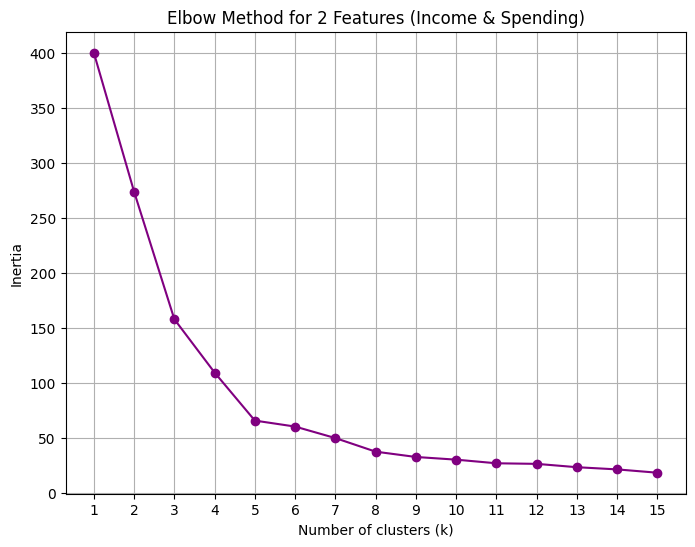

In [24]:

inertia_2f = []
k_range_2f = range(1, 16)

for k in k_range_2f:
    kmeans_2f = KMeans(n_clusters=k, random_state=42)
    kmeans_2f.fit(df_scaled_2f)
    inertia_2f.append(kmeans_2f.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(k_range_2f, inertia_2f, marker='o', color='purple')
plt.title('Elbow Method for 2 Features (Income & Spending)')
plt.xticks(k_range_2f)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [25]:

kmeans_2f = KMeans(n_clusters=5, random_state=42)
df['KMeans_2F_Cluster'] = kmeans_2f.fit_predict(df_scaled_2f)


In [26]:

kmeans_2f_silhouette = silhouette_score(df_scaled_2f, kmeans_2f.labels_)
kmeans_2f_db = davies_bouldin_score(df_scaled_2f, kmeans_2f.labels_)

print("K-Means (2 Features) Evaluation:")
print(f"Silhouette Score: {kmeans_2f_silhouette:.3f}")
print(f"Davies-Bouldin Score: {kmeans_2f_db:.3f}")

K-Means (2 Features) Evaluation:
Silhouette Score: 0.555
Davies-Bouldin Score: 0.572


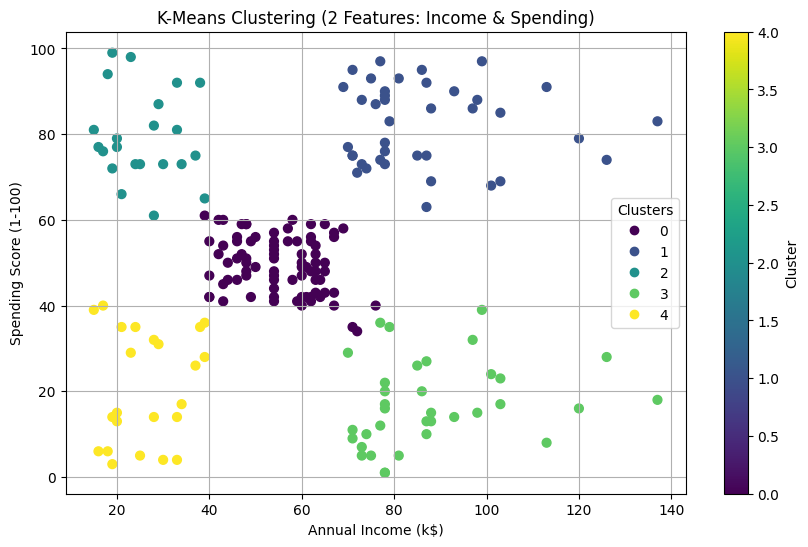

In [27]:

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],c=df['KMeans_2F_Cluster'],s=40)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clustering (2 Features: Income & Spending)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

In [28]:
cluster_summary = df.groupby('KMeans_Cluster').agg({
    'Age': ['min', 'max', 'mean'],
    'Annual Income (k$)': ['min', 'max', 'mean'],
    'Spending Score (1-100)': ['min', 'max', 'mean']
})
cluster_summary['Customer_Count'] = df.groupby('KMeans_Cluster').size()
cluster_summary = cluster_summary.round(2)

cluster_summary


cluster_summary_2f = df.groupby('KMeans_2F_Cluster').agg({
    'Age': ['min', 'max', 'mean'],
    'Annual Income (k$)': ['min', 'max', 'mean'],
    'Spending Score (1-100)': ['min', 'max', 'mean']
})
cluster_summary_2f['Customer_Count'] = df.groupby('KMeans_2F_Cluster').size()
cluster_summary_2f = cluster_summary_2f.round(2)

cluster_summary_2f

combined_summary = pd.concat(
    [cluster_summary, cluster_summary_2f],
    axis=1,
    keys=['KMeans (All Features)', 'KMeans (2 Features)']
)

combined_summary


KMeans (All Features)                                            \
                    Age            Annual Income (k$)               
                    min max   mean                min  max   mean   
0                    43  70  56.33                 38   79  54.27   
1                    27  40  32.69                 69  137  86.54   
2                    18  35  25.56                 15   42  26.48   
3                    18  40  26.12                 40   81  59.42   
4                    32  59  44.00                 71  137  90.13   
5                    20  67  45.52                 16   39  26.29   

                                                   KMeans (2 Features)        \
  Spending Score (1-100)            Customer_Count                 Age         
                     min max   mean                                min   max   
0                     35  60  49.07             45                18.0  70.0   
1                     63  97  82.13             39                27.0  40.0   
2                     39  99  76.24             25                18.0  35.0   
3                      5  60  44.45             40                19.0  59.0   
4                      1  39  17.93             30                19.0  67.0   
5                      3  40  19.38             21                 NaN   NaN   

                                                                               \
         Annual Income (k$)               Spending Score (1-100)                
    mean                min    max   mean                    min   max   mean   
0  42.72               39.0   76.0  55.30                   34.0  61.0  49.52   
1  32.69               69.0  137.0  86.54                   63.0  97.0  82.13   
2  25.27               15.0   39.0  25.73                   61.0  99.0  79.36   
3  41.11               70.0  137.0  88.20                    1.0  39.0  17.11   
4  45.22               15.0   39.0  26.30                    3.0  40.0  20.91   
5    NaN                NaN    NaN    NaN                    NaN   NaN    NaN   

                  
  Customer_Count  
                  
0           81.0  
1           39.0  
2           22.0  
3           35.0  
4           23.0  
5            NaN

---
From the above comparsion we can conclude the following:
* Although evaluation matrix give a better score for 2 features, 3 feature clustering divides better, as Age helps in further division.
* 3 feature cluster as even number of distribution in customer, whereas 2 feature has a dominant cluster with approx 40% of the customers.
* Comparison of 3D & 2D models based on matrix is not fare, CLustering is easy in 2D but looses patterns and trends. 

# Hence we conclude that using 3 features is better for finding patterns(CLustering)

---
## Agglomerative Clustering

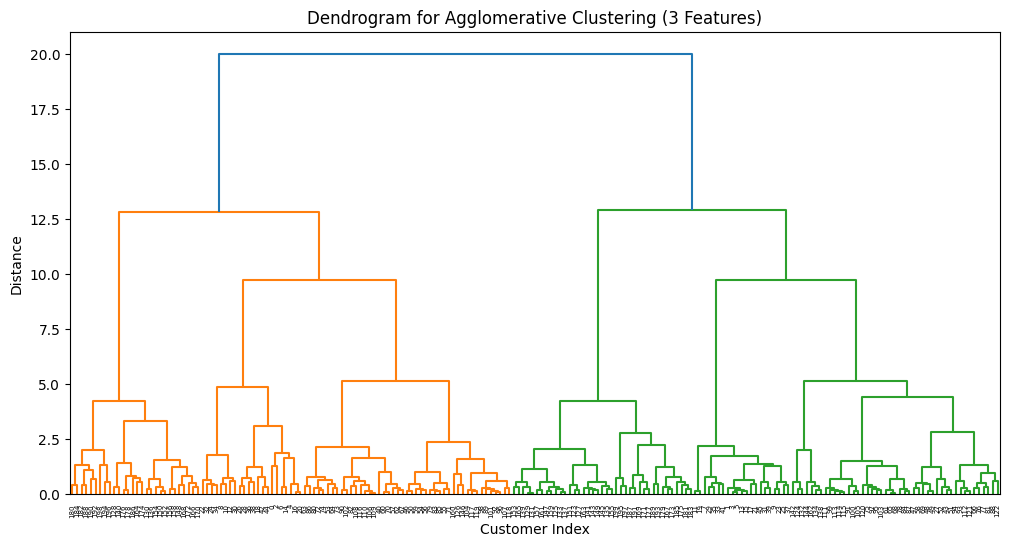

In [29]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

plt.figure(figsize=(12, 6))
linkage_matrix = linkage(df_scaled, method='ward')
dendrogram(linkage_matrix)
plt.title('Dendrogram for Agglomerative Clustering (3 Features)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()

In [30]:
agg_3f = AgglomerativeClustering(n_clusters=6, linkage='ward')
df['Agg_3F_Cluster'] = agg_3f.fit_predict(df_scaled)

In [31]:
agg_3f_silhouette = silhouette_score(df_scaled, df['Agg_3F_Cluster'])
agg_3f_db = davies_bouldin_score(df_scaled, df['Agg_3F_Cluster'])

print(f"Silhouette Score: {agg_3f_silhouette:.3f}")
print(f"Davies-Bouldin Score: {agg_3f_db:.3f}")

Silhouette Score: 0.420
Davies-Bouldin Score: 0.852


In [32]:
ig = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    z='Age',
    color='Agg_3F_Cluster',
    title='Agglomerative Clustering (3 Features)',
    color_continuous_scale='Rainbow'
)
fig.update_traces(marker=dict(size=3))
fig.show()

In [33]:
cluster_summary = df.groupby('Agg_3F_Cluster').agg({
    'Age': ['min', 'max', 'mean'],
    'Annual Income (k$)': ['min', 'max', 'mean'],
    'Spending Score (1-100)': ['min', 'max', 'mean']
})
cluster_summary['Customer_Count'] = df.groupby('Agg_3F_Cluster').size()
cluster_summary = cluster_summary.round(2)

cluster_summary

Age            Annual Income (k$)              \
               min max   mean                min  max   mean   
Agg_3F_Cluster                                                 
0               18  45  27.38                 28   81  57.51   
1               43  70  56.40                 38   79  55.29   
2               27  40  32.69                 69  137  86.54   
3               32  59  43.89                 71  137  91.29   
4               19  67  44.32                 15   39  25.77   
5               18  35  24.81                 15   39  25.62   

               Spending Score (1-100)            Customer_Count  
                                  min max   mean                 
Agg_3F_Cluster                                                   
0                                   5  61  45.84             45  
1                                  35  60  48.36             45  
2                                  63  97  82.13             39  
3                                   1  39  16.68             28  
4                                   3  40  20.27             22  
5                                  65  99  80.24             21

## Divisive CLustering

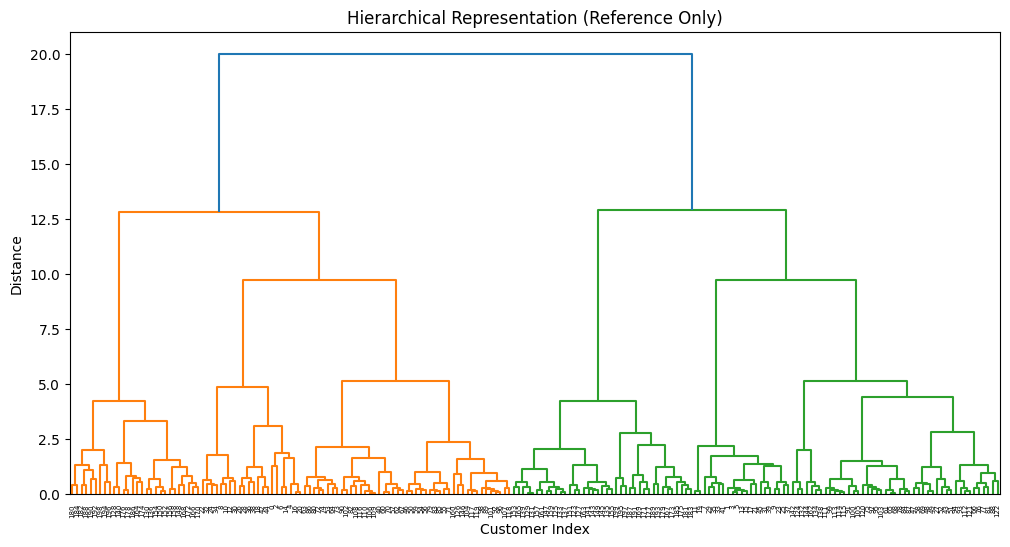

In [34]:
from sklearn.cluster import BisectingKMeans
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(df_scaled, method='ward')
dendrogram(linkage_matrix)
plt.title('Hierarchical Representation (Reference Only)')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.show()


In [35]:
bk_3f = BisectingKMeans(
    n_clusters=6,
    random_state=42
)

df['Div_3F_Cluster'] = bk_3f.fit_predict(df_scaled)


In [36]:
div_silhouette = silhouette_score(df_scaled, df['Div_3F_Cluster'])
div_db = davies_bouldin_score(df_scaled, df['Div_3F_Cluster'])

print(f"Silhouette Score: {div_silhouette:.3f}")
print(f"Davies-Bouldin Score: {div_db:.3f}")


Silhouette Score: 0.361
Davies-Bouldin Score: 0.955


In [37]:
fig = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    z='Age',
    color='Div_3F_Cluster',
    title='Divisive Clustering using Bisecting KMeans (3 Features)',
    color_continuous_scale='Rainbow'
)

fig.update_traces(marker=dict(size=3))
fig.show()


In [38]:
cluster_summary_div = df.groupby('Div_3F_Cluster').agg({
    'Age': ['min', 'max', 'mean'],
    'Annual Income (k$)': ['min', 'max', 'mean'],
    'Spending Score (1-100)': ['min', 'max', 'mean']
})

cluster_summary_div['Customer_Count'] = df.groupby('Div_3F_Cluster').size()
cluster_summary_div = cluster_summary_div.round(2)

cluster_summary_div


Age            Annual Income (k$)              \
               min max   mean                min  max   mean   
Div_3F_Cluster                                                 
0               18  38  27.08                 15   54  29.19   
1               40  70  55.64                 38   79  54.38   
2               35  67  49.90                 18   75  34.55   
3               19  59  38.67                 64  137  87.25   
4               27  40  32.88                 69  137  86.10   
5               18  34  22.62                 46   67  58.52   

               Spending Score (1-100)            Customer_Count  
                                  min max   mean                 
Div_3F_Cluster                                                   
0                                   6  99  65.56             36  
1                                  35  60  48.85             47  
2                                   3  36  15.80             20  
3                                   1  42  20.28             36  
4                                  58  97  81.53             40  
5                                  41  60  51.29             21

DBSCAN

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


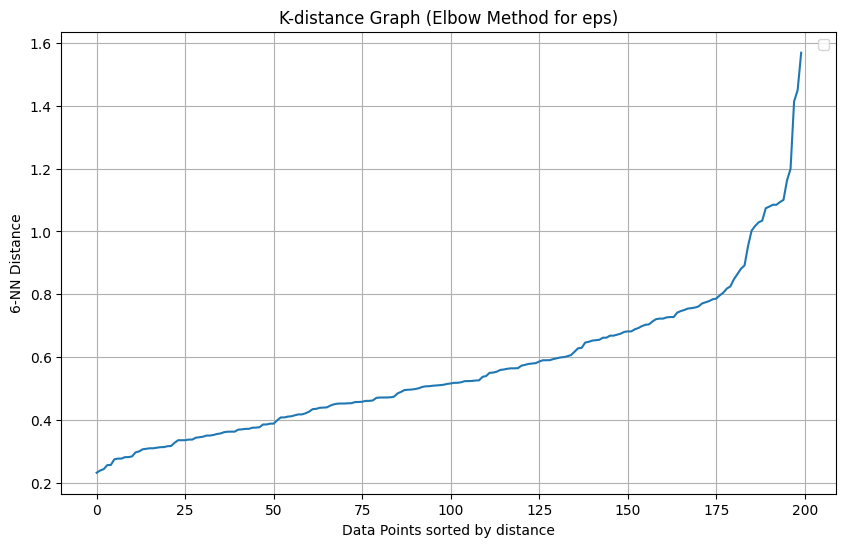

In [39]:
from sklearn.neighbors import NearestNeighbors
min_samples = 6

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Sort distances
distances = np.sort(distances[:, min_samples-1], axis=0)

# Plot K-distance Graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance Graph (Elbow Method for eps)')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'{min_samples}-NN Distance')
plt.grid(True)
plt.legend()
plt.show()

In [40]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)
n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'] else 0)
n_noise = list(df['DBSCAN_Cluster']).count(-1)
print(f"\nNumber of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise}")


Number of clusters: 7
Number of noise points: 60


In [41]:
mask = df['DBSCAN_Cluster'] != -1
if mask.sum() > 0:
        dbscan_silhouette = silhouette_score(df_scaled[mask], df['DBSCAN_Cluster'][mask])
        dbscan_db = davies_bouldin_score(df_scaled[mask], df['DBSCAN_Cluster'][mask])
        print(f"Silhouette Score: {dbscan_silhouette:.3f}")
        print(f"Davies-Bouldin Score: {dbscan_db:.3f}")


Silhouette Score: 0.482
Davies-Bouldin Score: 0.639


In [42]:
# 3D Visualization
fig = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    z='Age',
    color='DBSCAN_Cluster',
    title='DBSCAN Clustering',
    color_continuous_scale='Rainbow'
)
fig.update_traces(marker=dict(size=3))
fig.show()

In [43]:

cluster_summary = df.groupby('DBSCAN_Cluster').agg({
    'Age': ['min', 'max', 'mean'],
    'Annual Income (k$)': ['min', 'max', 'mean'],
    'Spending Score (1-100)': ['min', 'max', 'mean']
})
cluster_summary['Customer_Count'] = df.groupby('DBSCAN_Cluster').size()
cluster_summary = cluster_summary.round(2)

cluster_summary

Age            Annual Income (k$)              \
               min max   mean                min  max   mean   
DBSCAN_Cluster                                                 
-1              19  67  40.13                 15  137  68.53   
 0              18  31  23.76                 15   38  25.82   
 1              35  45  38.20                 21   37  27.80   
 2              32  70  53.67                 39   67  54.16   
 3              18  33  24.11                 39   72  54.32   
 4              27  40  32.75                 69  103  80.88   
 5              40  47  43.86                 71   87  78.71   

               Spending Score (1-100)            Customer_Count  
                                  min max   mean                 
DBSCAN_Cluster                                                   
-1                                  1  99  31.53             60  
 0                                 66  92  78.18             17  
 1                                 26  35  31.80              5  
 2                                 28  60  48.41             51  
 3                                 34  61  50.46             28  
 4                                 69  97  83.62             32  
 5                                  7  20  14.57              7


Here we can see DBSCAN offers a higher Silhouette Score and a lower Davies-Bouldin Score which is good. Data loss is higher due to higher noise.

---
## PCA

In [44]:
df_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [45]:
from sklearn.decomposition import PCA
pca_2 = PCA(n_components=2)
df_pca = pca_2.fit_transform(df_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca.head()

,PC1,PC2
0,-0.615720,-1.763481
1,-1.665793,-1.820747
2,0.337862,-1.674799
3,-1.456573,-1.772430
4,-0.038465,-1.662740


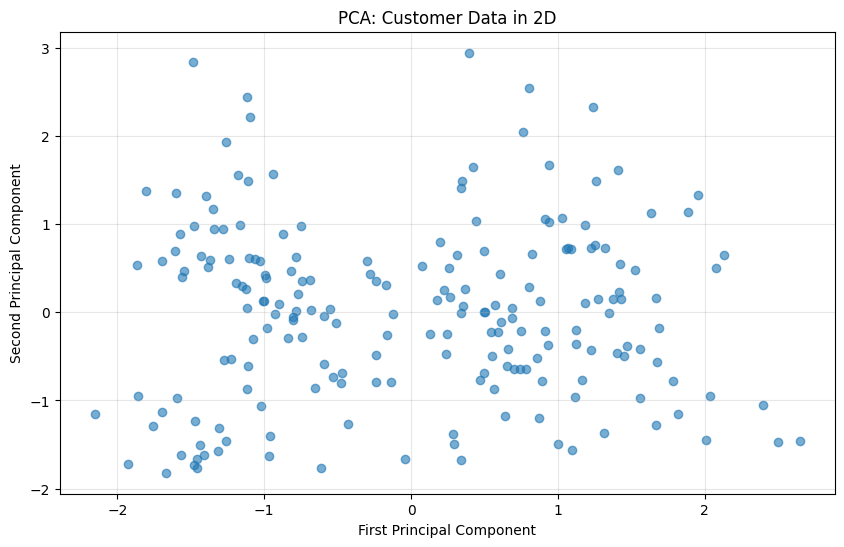

In [46]:

plt.figure(figsize=(10, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.6)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA: Customer Data in 2D')
plt.grid(True, alpha=0.3)

## K-mean with PCA

In [47]:
kmeans_pca = KMeans(n_clusters=6, random_state=42)
df['KMeans_PCA'] = kmeans_pca.fit_predict(df_pca)

In [48]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y='Age',
    z='Spending Score (1-100)',
    color=df['KMeans_PCA']
)

fig.update_traces(marker=dict(size=4))
fig.show()

In [49]:
kmeans_pca_sil = silhouette_score(df_pca, df['KMeans_PCA'])
kmeans_pca_db = davies_bouldin_score(df_pca, df['KMeans_PCA'])


print("K-Means PCA Evaluation:")
print(f"Silhouette Score: {kmeans_pca_sil:.3f}")
print(f"Davies-Bouldin Score: {kmeans_pca_db:.3f}")


K-Means PCA Evaluation:
Silhouette Score: 0.352
Davies-Bouldin Score: 0.935


## Hence Result is detoriating when PCA is used.

----
-----

## Final Result & Analysis:

I'll consider the K-Means clustering on the original three features (Age, Annual Income, Spending Score) as the most effective approach for customer segmentation in this dataset. This method provided a good balance of cluster interpretability and evaluation metrics, while ensuring no dominance of one group.

## Clustering summary

In [50]:
cluster_summary = df.groupby('KMeans_Cluster').agg({
    'Age': ['min', 'max', 'mean'],
    'Annual Income (k$)': ['min', 'max', 'mean'],
    'Spending Score (1-100)': ['min', 'max', 'mean']
})
cluster_summary['Customer_Count'] = df.groupby('KMeans_Cluster').size()
cluster_summary['Male_Count'] = df.groupby('KMeans_Cluster')['Genre'].sum()
cluster_summary['Female_Count'] = df.groupby('KMeans_Cluster')['Genre'].apply(lambda x: (x == 0).sum())
cluster_summary = cluster_summary.round(2)

cluster_summary


Age            Annual Income (k$)              \
               min max   mean                min  max   mean   
KMeans_Cluster                                                 
0               43  70  56.33                 38   79  54.27   
1               27  40  32.69                 69  137  86.54   
2               18  35  25.56                 15   42  26.48   
3               18  40  26.12                 40   81  59.42   
4               32  59  44.00                 71  137  90.13   
5               20  67  45.52                 16   39  26.29   

               Spending Score (1-100)            Customer_Count Male_Count  \
                                  min max   mean                             
KMeans_Cluster                                                               
0                                  35  60  49.07             45         19   
1                                  63  97  82.13             39         18   
2                                  39  99  76.24             25         11   
3                                   5  60  44.45             40         16   
4                                   1  39  17.93             30         16   
5                                   3  40  19.38             21          8   

               Female_Count  
                             
KMeans_Cluster               
0                        26  
1                        21  
2                        14  
3                        24  
4                        14  
5                        13

## Visualization of CLusters

In [51]:
import plotly.express as px # type: ignore
fig = px.scatter_3d(
    df,
    x='Annual Income (k$)',
    y="Spending Score (1-100)",
    z="Age",
    color="KMeans_Cluster",
    color_continuous_scale="Viridis"
)


fig.update_traces(marker=dict(size=3))

fig.show()


## Cluster Profiling:

In [52]:
cluster_insights = pd.DataFrame({
    'Cluster': [0, 1, 2, 3, 4, 5],
    'Segment_Name': [
        'Young avg-income, avg-spending',
        'Older avg-income, avg-spending',
        'High Income, Low Spending',
        'Low Income, Low Spending ',
        'Young low-income, high-spending(Teen Kids)',
        'Avg Age, High Income, High Spending'
    ],
    'Customer_Count': [38, 45, 34, 21, 23, 39],
    'Male_Count': [13,19,20,8,10,18],
    'Female_Count': [25,26,14,13,13,21],
    'Min_Age': [18, 43, 19, 20, 18, 27],
    'Max_Age': [40, 70, 59, 67, 35, 40],
    'Avg_Age': [27.0, 56.3, 41.3, 45.5, 25.0, 32.7],
    'Min_Income': [39,38,71,16,15,69],
    'Max_Income': [76,79,137,39,39,137],
    'Avg_Income': [56.7, 54.3, 88.5, 26.3, 25.3, 86.5],
    'Min_Spending': [29,35,1,3,39,63],
    'Max_Spending': [61,60,39,40,99,97],
    'Avg_Spending': [49.1, 49.1, 16.8, 19.4, 77.6, 82.1],
    
})

cluster_insights

,Cluster,Segment_Name,Customer_Count,Male_Count,Female_Count,Min_Age,Max_Age,Avg_Age,Min_Income,Max_Income,Avg_Income,Min_Spending,Max_Spending,Avg_Spending
0,0,"Young avg-income, avg-spending",38,13,25,18,40,27.0,39,76,56.7,29,61,49.1
1,1,"Older avg-income, avg-spending",45,19,26,43,70,56.3,38,79,54.3,35,60,49.1
2,2,"High Income, Low Spending",34,20,14,19,59,41.3,71,137,88.5,1,39,16.8
3,3,"Low Income, Low Spending",21,8,13,20,67,45.5,16,39,26.3,3,40,19.4
4,4,"Young low-income, high-spending(Teen Kids)",23,10,13,18,35,25.0,15,39,25.3,39,99,77.6
5,5,"Avg Age, High Income, High Spending",39,18,21,27,40,32.7,69,137,86.5,63,97,82.1


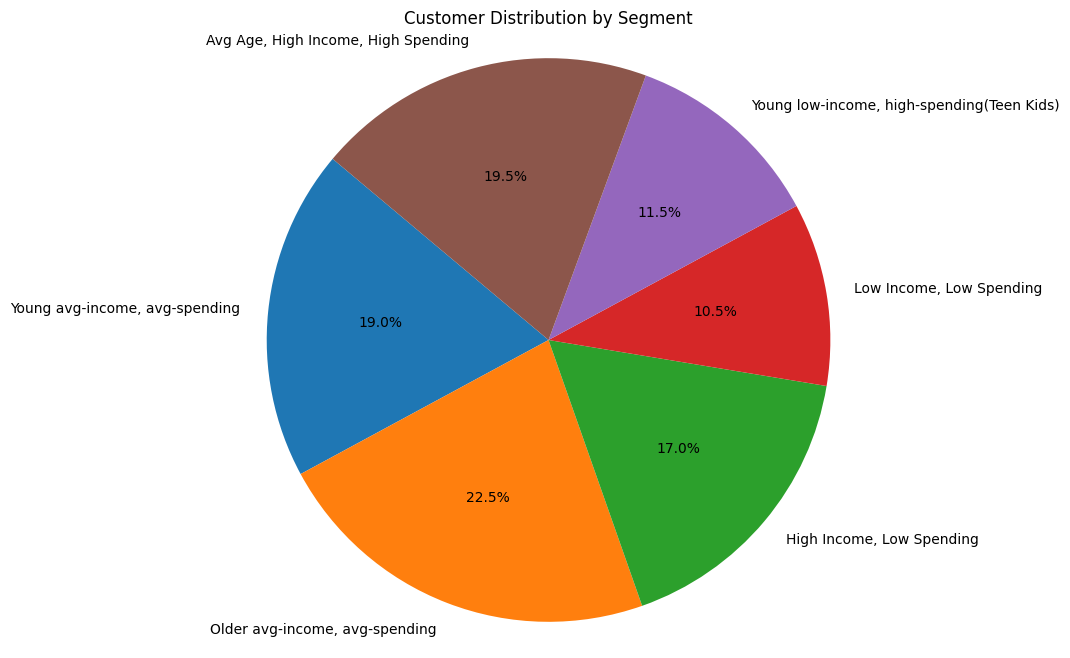

In [53]:
import matplotlib.pyplot as plt

counts =cluster_insights['Customer_Count']
labels = cluster_insights['Segment_Name']

plt.figure(figsize=(8, 8))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Customer Distribution by Segment')
plt.axis('equal')
plt.show()


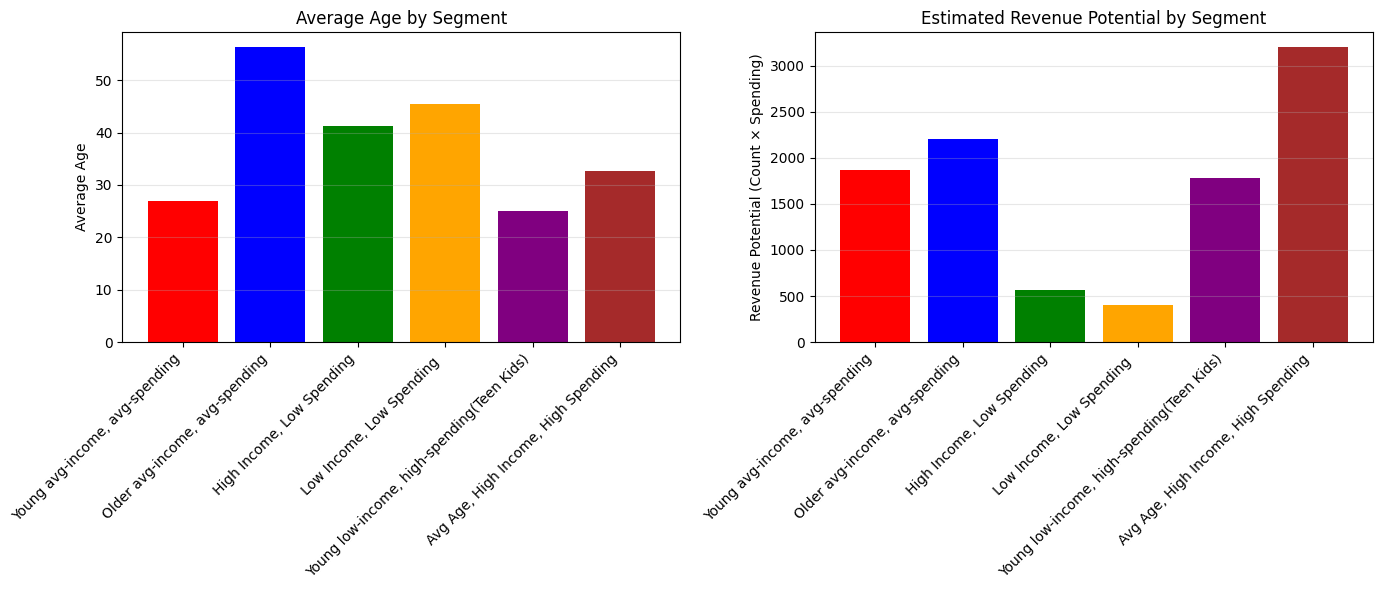

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segment_names = cluster_insights['Segment_Name'].tolist()
n_segments = len(segment_names)

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown'][:n_segments]

axes[0].bar(range(n_segments), cluster_insights['Avg_Age'], color=colors)
axes[0].set_xticks(range(n_segments))
axes[0].set_xticklabels(segment_names, rotation=45, ha='right')
axes[0].set_ylabel('Average Age')
axes[0].set_title('Average Age by Segment')
axes[0].grid(axis='y', alpha=0.3)

revenue_potential = (
    cluster_insights['Customer_Count'] *
    cluster_insights['Avg_Spending']
)

axes[1].bar(range(n_segments), revenue_potential, color=colors)
axes[1].set_xticks(range(n_segments))
axes[1].set_xticklabels(segment_names, rotation=45, ha='right')
axes[1].set_ylabel('Revenue Potential (Count × Spending)')
axes[1].set_title('Estimated Revenue Potential by Segment')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Save Model and Data for Streamlit App

In [55]:
import pickle

# Save the trained K-Means model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save cluster insights
cluster_insights.to_csv('cluster_insights.csv', index=False)





In [56]:
filtered_rows = df[(df['Age'] > 65.00) &
                   (df['Annual Income (k$)'] >80.00) & 
                   (df['Spending Score (1-100)'] > 80.00)]

filtered_rows


,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,KMeans_2F_Cluster,Agg_3F_Cluster,Div_3F_Cluster,DBSCAN_Cluster,KMeans_PCA


In [57]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster,KMeans_2F_Cluster,Agg_3F_Cluster,Div_3F_Cluster,DBSCAN_Cluster,KMeans_PCA
0,1,19,15,39,2,4,4,0,-1,2
1,1,21,15,81,2,2,5,0,0,2
2,0,20,16,6,5,4,4,0,-1,4
3,0,23,16,77,2,2,5,0,0,2
4,0,31,17,40,5,4,4,0,-1,4
